In [20]:
import geopandas as gpd
import osmnx as ox

In [21]:
# carregar o shp dos municipios
caminho_shp = "BR_Municipios_2024/BR_Municipios_2024.shp"
df_municipios = gpd.read_file(caminho_shp)

In [22]:
df_municipios

,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,CD_CONCU,NM_CONCU,AREA_KM2,geometry
0,2504108,Carrapateira,250015,Cajazeiras,2504,Sousa - Cajazeiras,25,Paraíba,PB,2,Nordeste,NE,None,None,59.070,"POLYGON ((-38.33672 -6.99279, -38.33653 -6.993..."
1,1718451,Pugmil,170003,Paraíso do Tocantins,1701,Palmas,17,Tocantins,TO,1,Norte,N,None,None,401.174,"POLYGON ((-48.91085 -10.53824, -48.911 -10.538..."
2,2104206,Fortuna,210016,Presidente Dutra,2104,Presidente Dutra,21,Maranhão,MA,2,Nordeste,NE,None,None,835.668,"POLYGON ((-43.95962 -5.49793, -43.96181 -5.497..."
3,5219902,São Francisco de Goiás,520002,Anápolis,5201,Goiânia,52,Goiás,GO,5,Centro-oeste,CO,None,None,416.535,"POLYGON ((-49.29477 -16.00852, -49.29484 -16.0..."
4,2708600,São Miguel dos Campos,270004,São Miguel dos Campos,2701,Maceió,27,Alagoas,AL,2,Nordeste,NE,None,None,335.679,"POLYGON ((-36.0739 -9.70094, -36.07339 -9.7008..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5568,2928307,Santanópolis,290029,Feira de Santana,2910,Feira de Santana,29,Bahia,BA,2,Nordeste,NE,None,None,222.686,"POLYGON ((-38.89821 -11.97859, -38.89819 -11.9..."
5569,1505635,Piçarra,150009,Marabá,1503,Marabá,15,Pará,PA,1,Norte,N,None,None,3312.703,"POLYGON ((-48.75692 -6.71744, -48.75783 -6.718..."
5570,2904308,Brejões,290003,Santo Antônio de Jesus,2902,Santo Antônio de Jesus,29,Bahia,BA,2,Nordeste,NE,None,None,518.566,"POLYGON ((-39.83791 -13.18942, -39.83802 -13.1..."
5571,1713205,Miracema do Tocantins,170004,Miracema do Tocantins,1701,Palmas,17,Tocantins,TO,1,Norte,N,None,None,2663.745,"POLYGON ((-48.81027 -10.04831, -48.81028 -10.0..."


In [23]:
# escolhendo um municipio
nome_alvo = 'Poços de Caldas'
municipio_alvo = df_municipios[df_municipios['NM_MUN'] == nome_alvo].copy()


Município escolhido: Poços de Caldas


<Axes: >

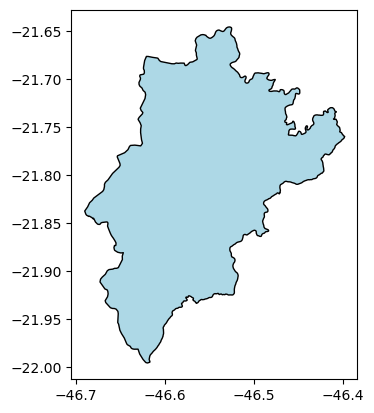

In [24]:
# Vizualizando o município
print(f"Município escolhido: {nome_alvo}")
municipio_alvo.plot(color='lightblue', edgecolor='black')

C:\Users\carol\AppData\Local\Temp\ipykernel_15788\3963903387.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geometria = municipio_alvo.geometry.unary_union


<Axes: >

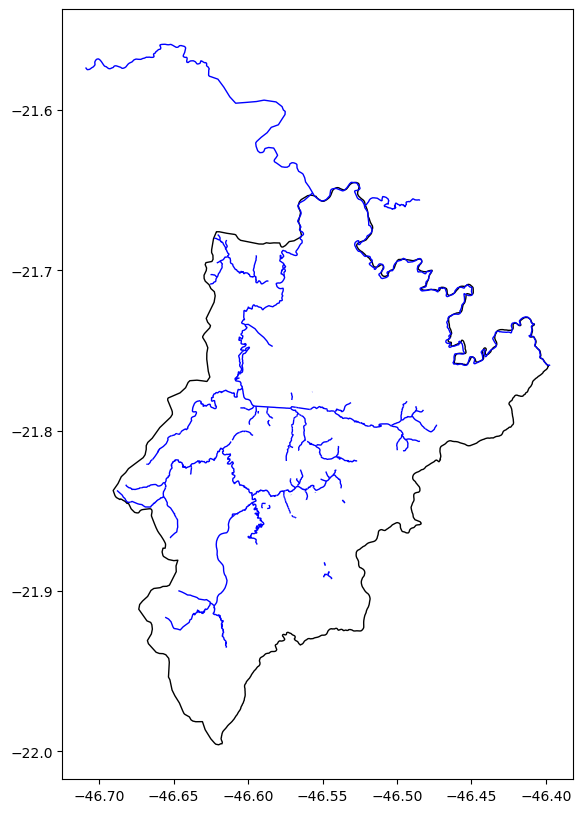

In [25]:


# Pegar a geometria do municipio escolhido

geometria = municipio_alvo.geometry.unary_union

# Baixar a drenagem 

rios = ox.features_from_polygon(geometria,
tags={'waterway': True})

# Filtrar para manter as linhas apenas
rios = rios[rios.geometry.type.isin(['LineString', 'MultiLineString'])]

# Plotar 
ax = municipio_alvo.plot(color='white',
edgecolor='black', figsize=(10, 10))
rios.plot(ax=ax, color='blue', linewidth=1)

In [26]:
import matplotlib.pyplot as plt

In [27]:
# Reprojetando
municipio_prj = municipio_alvo.to_crs(epsg=31983)
rios_prj = rios.to_crs(epsg=31983)

In [28]:
# Calcular estatísticas 
# Área em km² 
area_km2 = municipio_prj.geometry.area.sum()/1_000_000

# Extensão em km
extensao_km = rios_prj.geometry.length.sum()/1_000

# Número de trechos de rios
trechos = len(rios_prj)
# Densidade de drenagem (km/km²)
densidade_drenagem = extensao_km/area_km2

# Imprimir resultados
print(f"Área do município: {area_km2:.1f} km²")
print(f"Extensão total dos rios: {extensao_km:.1f} km")
print(f"Número de trechos de rios: {trechos}")
print(f"Densidade de drenagem: {densidade_drenagem:.2f} km/km²")

Área do município: 546.9 km²
Extensão total dos rios: 268.5 km
Número de trechos de rios: 249
Densidade de drenagem: 0.49 km/km²


In [29]:
import shapely
from shapely.affinity import translate

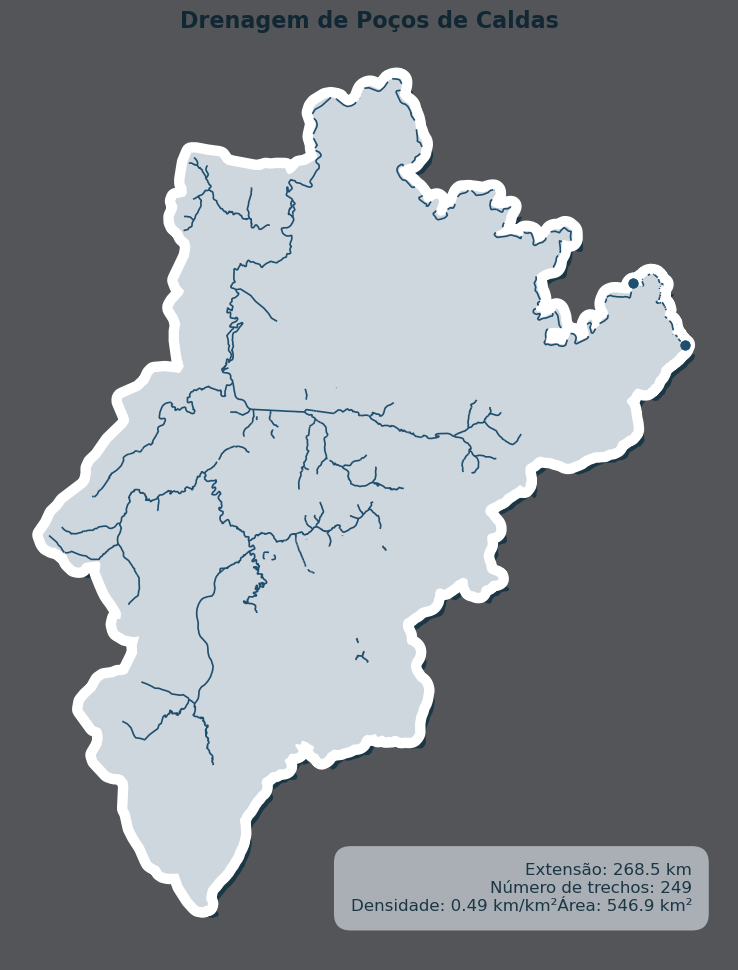

In [34]:
# Criando grafico com efeito 3D
fig, ax = plt.subplots(figsize=(12, 12))

# Cor do fundo
fig.patch.set_facecolor("#535558")
ax.set_facecolor('#535558')
ax.axis('off')

# Camada 1: sombra
sombra_geom = municipio_prj.geometry.apply(lambda g: translate(g, xoff=500, yoff=-500))
gpd.GeoSeries(sombra_geom).plot(ax=ax, color='#1b3644', edgecolor='none')

# Camada 2: borda branca, plotamos o município com borda branca para criar o efeito de relevo
municipio_prj.plot(ax=ax, color='none', edgecolor='white', linewidth=15)

# Camada 3: O polígono principal
municipio_prj.plot(ax=ax, color='#ced6de')

# Camada 4: rios
rios_cortados = gpd.clip(rios_prj, municipio_prj)
rios_cortados.plot(ax=ax, color='#1f4f6e', linewidth=1.2)

# Dados de drenagem 
texto_stats = (f"Extensão: {extensao_km:.1f} km\n"
               f"Número de trechos: {trechos}\n"
               f"Densidade: {densidade_drenagem:.2f} km/km²"
               f"Área: {area_km2:.1f} km²"
               )

# Adicionar caixa de texto
ax.text(0.95, 0.05, texto_stats, transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom',
        horizontalalignment='right', color='#1b3644', family='sans-serif',
        bbox=dict( facecolor='#ced6de', alpha=0.7,  edgecolor='none', boxstyle='round,pad=1')
        )


plt.title(f"Drenagem de {nome_alvo}", fontsize=16, fontweight='bold', color="#112834")
plt.show()

